# **INPUT IMAGES**

In [1]:
import struct
import numpy as np

def parse_mnist_images(filename):
    with open(filename, 'rb') as f:
        # Read the header information
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        # Read the image data
        images = np.fromfile(f, dtype=np.uint8).reshape(num_images, rows, cols)
    return images

def parse_mnist_labels(filename):
    with open(filename, 'rb') as f:
        # Read the header information
        magic, num_labels = struct.unpack(">II", f.read(8))
        # Read the label data
        labels = np.fromfile(f, dtype=np.uint8)
    return labels

# Load the training data
train_images = parse_mnist_images('train-images.idx3-ubyte_')
train_labels = parse_mnist_labels('train-labels.idx1-ubyte_')

# Load the test data
test_images = parse_mnist_images('t10k-images.idx3-ubyte_')
test_labels = parse_mnist_labels('t10k-labels.idx1-ubyte_')

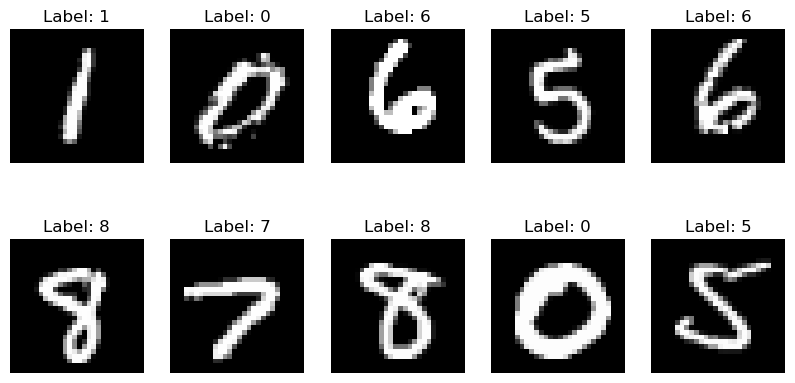

In [2]:
# visualize some images
import matplotlib.pyplot as plt
import random

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(2):
    for j in range(5):
        idx = random.randint(0, test_images.shape[0])
        axes[i, j].imshow(test_images[idx], cmap='gray')
        axes[i, j].set_title(f"Label: {test_labels[idx]}")
        axes[i, j].axis('off')

plt.show()

In [3]:
def calculate_priors(y):
    classes, counts = np.unique(y, return_counts=True)
    priors = counts / len(y)
    return priors

In [4]:
import numpy as np
import struct

class NaiveBayesClassifier:
    def __init__(self, mode='discrete'):
        self.mode = mode
        self.priors = None
        self.likelihoods = None
        self.means = None
        self.variances = None
        self.num_classes = 10
        self.num_bins = 32
    
    def fit(self, X, y):
        if self.mode == 'discrete':
            self._fit_discrete(X, y)
        else:
            self._fit_continuous(X, y)
    
    def predict(self, X):
        if self.mode == 'discrete':
            return self._predict_discrete(X)
        else:
            return self._predict_continuous(X)
    
    def _fit_discrete(self, X, y):
        self.priors = calculate_priors(y)
        self.likelihoods = np.zeros((self.num_classes, X.shape[1], self.num_bins))

        # Bin pixel values into discrete categories
        X_binned = (X // (256 // self.num_bins)).astype(int)

        # Calculate likelihoods with Laplace smoothing
        for c in range(self.num_classes):
            X_class = X_binned[y == c]
            for i in range(X.shape[1]):
                for b in range(self.num_bins):
                    self.likelihoods[c, i, b] = np.sum(X_class[:, i] == b) + 1
                self.likelihoods[c, i] /= len(X_class) + self.num_bins
    
    def _predict_discrete(self, X):
        X_binned = (X // (256 // self.num_bins)).astype(int)
        log_posteriors = np.zeros((X.shape[0], self.num_classes))
        
        for i in range(X.shape[0]):
            print("Image",i,":")
            for c in range(self.num_classes):
                log_posteriors[i, c] = np.log(self.priors[c])
                for j in range(X.shape[1]):
                    log_posteriors[i, c] += np.log(self.likelihoods[c, j, X_binned[i, j]])
                
            
            # compute the sum and divide each posterior by the sum to normalize
            posteriors = log_posteriors[i]
            sum_posteriors = np.sum(posteriors)
            log_posteriors[i] = posteriors / sum_posteriors

            # print the log likelihoods for each class for each image
            for c in range(self.num_classes):
                print(c,":",log_posteriors[i, c])

        
        return np.argmin(log_posteriors, axis=1)
    
    def _fit_continuous(self, X, y):
        self.priors = calculate_priors(y)
        self.means = np.zeros((self.num_classes, X.shape[1]))
        self.variances = np.zeros((self.num_classes, X.shape[1]))

        for c in range(self.num_classes):
            X_class = X[y == c]
            self.means[c, :] = np.mean(X_class, axis=0)
            self.variances[c, :] = np.var(X_class, axis=0) + 1e-2
    
    def _predict_continuous(self, X):
        log_posteriors = np.zeros((X.shape[0], self.num_classes))

        for i in range(X.shape[0]):
            print("Image",i,":")
            for c in range(self.num_classes):
                log_posteriors[i, c] = np.log(self.priors[c])
                for j in range(X.shape[1]):
                    mean = self.means[c, j]
                    var = self.variances[c, j]
                    log_posteriors[i, c] += -0.5 * np.log(2 * np.pi * var) - ((X[i, j] - mean) ** 2) / (2 * var)
                
            # compute the sum and divide each posterior by the sum to normalize
            posteriors = log_posteriors[i]
            sum_posteriors = np.sum(posteriors)
            log_posteriors[i] = posteriors / sum_posteriors

            # print the log likelihoods for each class for each image
            for c in range(self.num_classes):
                print(c,":",log_posteriors[i, c])
        
        return np.argmin(log_posteriors, axis=1)
    
    def print_imagination(self):
        print("Imagination of numbers in Bayesian classifier:")
        if self.mode == 'discrete':
            for c in range(self.num_classes):
                image = np.zeros((28, 28))
                for i in range(28):
                    for j in range(28):
                        bin_idx = np.argmax(self.likelihoods[c, i * 28 + j])
                        image[i, j] = 1 if bin_idx >= (self.num_bins // 2) else 0
                print(f"{c}:")
                for row in image:
                    print("".join(['1' if pixel == 1 else '0' for pixel in row]))
        else:
            for c in range(self.num_classes):
                image = np.zeros((28, 28))
                for i in range(28):
                    for j in range(28):
                        if self.means[c, i * 28 + j] > 128:
                            image[i, j] = 1
                        else:
                            image[i, j] = 0
                print(f"{c}:")
                for row in image:
                    print("".join(['1' if pixel == 1 else '0' for pixel in row]))

In [5]:
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    correct_predictions = np.sum(predictions == y_test)
    error_rate = 1 - (correct_predictions / len(y_test))
    
    print("Posterior (in log scale):")
    for i in range(len(X_test)):
        print(f"Image {i}: {predictions[i]}, Answer: {y_test[i]}")
    
    print(f"Error rate: {error_rate * 100:.2f}%")
    return error_rate

In [6]:
def run_naive_bayes(train_images, train_labels, test_images, test_labels, mode):
    
    if mode == 0:
        mode = 'discrete'
    else:
        mode = 'continuous'

    # Reshape images for classification
    train_images = train_images.reshape(len(train_images), -1)
    test_images = test_images.reshape(len(test_images), -1)
    
    # Initialize and train the model
    nb_classifier = NaiveBayesClassifier(mode=mode)
    nb_classifier.fit(train_images, train_labels)

    # Evaluate on test data
    evaluate_model(nb_classifier, test_images, test_labels)
    
    # Print imagination of numbers
    nb_classifier.print_imagination()

In [7]:
run_naive_bayes(train_images, train_labels, test_images, test_labels, 1)

Image 0 :
0 : 0.27635356086509544
1 : 0.10354848289719884
2 : 0.27643890902764706
3 : 0.00018108871710122704
4 : 0.00016004245687362693
5 : 0.0001404572352646321
6 : 0.34277522504477376
7 : 0.00010168968924243952
8 : 0.00019928897248997797
9 : 0.00010125509431311556
Image 1 :
0 : 0.0014087231905626954
1 : 0.0005137424397219498
2 : 9.216588646929875e-05
3 : 0.04024687668347274
4 : 0.030531758038468346
5 : 0.0002543047995250361
6 : 0.00026289751962422196
7 : 0.49771169295244855
8 : 0.030967929231834595
9 : 0.39800990925787266
Image 2 :
0 : 0.0007267959246713626
1 : 0.00045844757649626285
2 : 0.0007117055890501823
3 : 0.0006686794791832287
4 : 0.0006778686063498482
5 : 0.0006793711091286357
6 : 0.0006373583511197394
7 : 0.9940373340134022
8 : 0.0006324058318750879
9 : 0.0007700335187235261
Image 3 :
0 : 0.04143555024348565
1 : 0.4647368629306146
2 : 0.051504452623140885
3 : 0.04876623619538076
4 : 0.051651648151639605
5 : 0.048613273886564404
6 : 0.044463865702755546
7 : 0.145621105163308

In [8]:
run_naive_bayes(train_images, train_labels, test_images, test_labels, 0)

Image 0 :
0 : 0.11115533817604589
1 : 0.11763260092591118
2 : 0.10517186686202931
3 : 0.100137502169675
4 : 0.09389200359742099
5 : 0.09755836271909257
6 : 0.11442027192059406
7 : 0.07444161841056393
8 : 0.09952134045842094
9 : 0.08606909476024607
Image 1 :
0 : 0.100200409517963
1 : 0.1070352761035449
2 : 0.08332998753571914
3 : 0.09034569728975578
4 : 0.10877362309335535
5 : 0.09252556976147994
6 : 0.08965940269603626
7 : 0.1189298263709533
8 : 0.0963398173153031
9 : 0.11286039031588922
Image 2 :
0 : 0.12847683719829553
1 : 0.06386485811570505
2 : 0.09868145466521333
3 : 0.10061294868354335
4 : 0.10342484486532438
5 : 0.0967118427966981
6 : 0.10335360293650774
7 : 0.10144903732164526
8 : 0.10041020791933995
9 : 0.10301436549772738
Image 3 :
0 : 0.07779623593480413
1 : 0.14086686086543018
2 : 0.09708059599688122
3 : 0.09653935618761733
4 : 0.10150694263616061
5 : 0.09270337417119959
6 : 0.09087672616895069
7 : 0.10268028676333292
8 : 0.09781592055626935
9 : 0.102133700719354
Image 4 :


# **Online Learning**

In [9]:
import math

def binomial_likelihood(k, n, p):
    # Calculate the binomial coefficient (n choose k)
    binom_coeff = math.comb(n, k)
    
    # Calculate the likelihood
    likelihood = binom_coeff * (p ** k) * ((1 - p) ** (n - k))
    
    return likelihood

def online_learning(filename, a, b):
    with open(filename, 'r') as f:
        for line in f:
            outcomes = list(map(int, list(line.strip())))
            k = sum(outcomes)  # Number of heads
            n = len(outcomes)  # Total number of coin tosses
            
            # MLE of p
            mle_p = k / n
            
            # Calculate the Binomial likelihood using the MLE for p
            likelihood = binomial_likelihood(k, n, mle_p)

            print(f"binomial likelihood: {likelihood}")
            print(f"Beta prior: a = {a}, b = {b}")
            
            # Update the Beta distribution parameters
            a = a + k
            b = b + (n - k)
            
            print(f"Beta posterior: a' = {a}, b' = {b}")
            print("")

# Example usage
online_learning('testfile.txt', a=10, b=1)


binomial likelihood: 0.16818809509277344
Beta prior: a = 10, b = 1
Beta posterior: a' = 21, b' = 12

binomial likelihood: 0.29375515303997485
Beta prior: a = 21, b = 12
Beta posterior: a' = 25, b' = 15

binomial likelihood: 0.2286054241794335
Beta prior: a = 25, b = 15
Beta posterior: a' = 32, b' = 20

binomial likelihood: 0.18286870706509092
Beta prior: a = 32, b = 20
Beta posterior: a' = 43, b' = 28

binomial likelihood: 0.2143070548857833
Beta prior: a = 43, b = 28
Beta posterior: a' = 53, b' = 33

binomial likelihood: 0.20659760529408
Beta prior: a = 53, b = 33
Beta posterior: a' = 62, b' = 39

binomial likelihood: 0.25082265600000003
Beta prior: a = 62, b = 39
Beta posterior: a' = 68, b' = 43

binomial likelihood: 0.2619678932864457
Beta prior: a = 68, b = 43
Beta posterior: a' = 76, b' = 46

binomial likelihood: 0.23609128871506807
Beta prior: a = 76, b = 46
Beta posterior: a' = 82, b' = 51

binomial likelihood: 0.27312909617436365
Beta prior: a = 82, b = 51
Beta posterior: a' = 